In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from astropy.table import Table, Row
from astropy.io import fits
import fitsio

from __future__ import print_function
import treecorr
import time
import pprint
%matplotlib inline

import scipy.integrate as integrate

# Using KiDS data to calculate weak lensing shear parameters

In [2]:
data1 = np.loadtxt('/user/p5_group/Rudrani/shear/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO1_Nz.asc')
data2 = np.loadtxt('/user/p5_group/Rudrani/shear/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO2_Nz.asc')
data3 = np.loadtxt('/user/p5_group/Rudrani/shear/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO3_Nz.asc')
data4 = np.loadtxt('/user/p5_group/Rudrani/shear/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO4_Nz.asc')
data5 = np.loadtxt('/user/p5_group/Rudrani/shear/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO5_Nz.asc')

In [3]:
diff1 = np.diff(data1, axis=0)
diff2 = np.diff(data2, axis=0)
diff3 = np.diff(data3, axis=0)
diff4 = np.diff(data4, axis=0)
diff5 = np.diff(data5, axis=0)

## Reproducing Fig. 2 of Asgari+2020

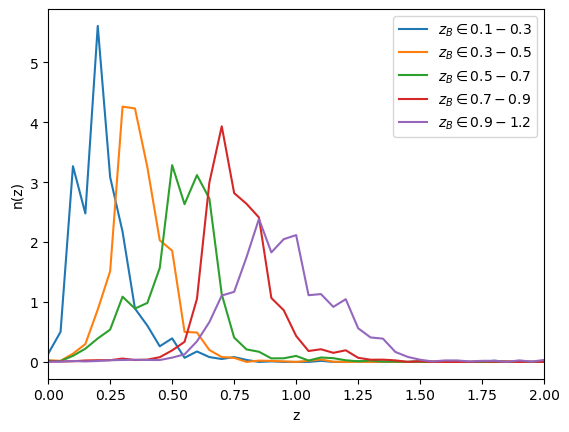

In [4]:
plt.plot(data1[:,0], data1[:,1]/0.05,label=r'$z_B \in 0.1-0.3$')
plt.plot(data2[:,0], data2[:,1]/0.05,label=r'$z_B \in 0.3-0.5$')
plt.plot(data3[:,0], data3[:,1]/0.05,label=r'$z_B \in 0.5-0.7$')
plt.plot(data4[:,0], data4[:,1]/0.05,label=r'$z_B \in 0.7-0.9$')
plt.plot(data5[:,0], data5[:,1]/0.05,label=r'$z_B \in 0.9-1.2$')
plt.xlim([0,2])
plt.xlabel('z')
plt.ylabel('n(z)')
plt.legend()

In [5]:
area1 = integrate.simpson(data1[:,1], x=np.argsort(data1[:,0]))
area2 = integrate.simpson(data2[:,1]/0.05, x=np.argsort(data2[:,0]))
area3 = integrate.simpson(data3[:,1]/0.05, x=np.argsort(data3[:,0]))
area4 = integrate.simpson(data4[:,1]/0.05, x=np.argsort(data4[:,0]))
area5 = integrate.simpson(data5[:,1]/0.05, x=np.argsort(data5[:,0]))

## Calculate area under each curve

In [6]:
sort_x1 =np.argsort(data1[:,0])
x1 = data1[:,0][sort_x1]
y1 = (data1[:,1]/0.05)[sort_x1]

x1_min = 0.1
x1_max = 0.3

mask1 = (x1 >= x1_min) & (x1 <= x1_max)
x1_cut = x1[mask1]
y1_cut = y1[mask1]

area1= integrate.simpson(y1_cut, x=x1_cut)

area1

np.float64(0.553845935747759)

In [7]:
sort_x2 =np.argsort(data2[:,0])
x2 = data2[:,0][sort_x2]
y2 = (data2[:,1]/0.05)[sort_x2]

x2_min = 0.3
x2_max = 0.5

mask2 = (x2 >= x2_min) & (x2 <= x2_max)
x2_cut = x2[mask2]
y2_cut = y2[mask2]

area2= integrate.simpson(y2_cut, x=x2_cut)

area2

np.float64(0.6275400448609265)

In [8]:
sort_x3 =np.argsort(data3[:,0])
x3 = data3[:,0][sort_x3]
y3 = (data3[:,1]/0.05)[sort_x3]

x3_min = 0.5
x3_max = 0.7

mask3 = (x3 >= x3_min) & (x3 <= x3_max)
x3_cut = x3[mask3]
y3_cut = y3[mask3]

area3= integrate.simpson(y3_cut, x=x3_cut)

area3

np.float64(0.43191686169810223)

In [9]:
sort_x4 =np.argsort(data4[:,0])
x4 = data4[:,0][sort_x4]
y4 = (data4[:,1]/0.05)[sort_x4]

x4_min = 0.7
x4_max = 0.9

mask4 = (x4 >= x4_min) & (x4 <= x4_max)
x4_cut = x4[mask4]
y4_cut = y4[mask4]

area4= integrate.simpson(y4_cut, x=x4_cut)

area4

np.float64(0.5197388167117099)

In [10]:
sort_x5 =np.argsort(data5[:,0])
x5 = data5[:,0][sort_x5]
y5 = (data5[:,1]/0.05)[sort_x5]

x5_min = 0.9
x5_max = 1.2

mask5 = (x5 >= x5_min) & (x5 <= x5_max)
x5_cut = x5[mask5]
y5_cut = y5[mask5]

area5= integrate.simpson(y5_cut, x=x5_cut)

area5

np.float64(0.38286003678526687)

# Check out the KiDS catalogue

In [11]:
with fits.open('/user/p5_group/Rudrani/shear/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits') as hdul:
    hd0 = hdul[0].header
    hd1 = hdul[1].header
    hd2 = hdul[2].header
    dt0 = hdul[0].data
    dt1 = hdul[1].data
    dt2 = hdul[2].data
    print(hd1)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  833 / length of dimension 1                          NAXIS2  =             21262011 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                  193 / number of table fields                         TTYPE1  = 'SeqNr   '           / Running object number within the catalogue     TCOMM1  = 'Running object number within the catalogue'                          TFORM1  = '1J      '                                                            TTYPE2  = 'SLID    '           / AstroWise Source list ID                       TCOMM2  = 'AstroWise Source list ID'    

In [12]:
fits.info('/user/p5_group/Rudrani/shear/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits')

Filename: /user/p5_group/Rudrani/shear/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1375   ()      
  1  OBJECTS       1 BinTableHDU    707   21262011R x 193C   [1J, 1J, 1J, 25A, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1I, 1I, 1I, 1I, 1I, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1D, 1D, 1I, 1J, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1J, 1J, 1J, 1J, 1J, 1J, 1E, 1J, 16A, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1

In [13]:
fits.getheader('/user/p5_group/Rudrani/shear/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits')

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
ORIGIN  = 'ESO-PARANAL'        / European Southern Observatory                  
TELESCOP= 'ESO-VST '           / ESO Telescope designation                      
INSTRUME= 'OMEGACAM'           / Instrument name                                
FILTER1 = 'u_SDSS  '           / Filter name                                    
FILTER2 = 'g_SDSS  '           / Filter name                                    
FILTER3 = 'r_SDSS  '           / Filter name                                    
FILTER4 = 'i_SDSS  '           / Filter name                                    
PROG_ID = 'MULTI   '           /                                                
OBSTECH = 'IMAGE,DITHER'    

In [14]:
hdu = fits.PrimaryHDU()
hdu.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  

In [15]:
dat = fits.getdata('/user/p5_group/Rudrani/shear/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits',1)



In [16]:
zb = dat['Z_B']
zbmin = dat['Z_B_MIN']
zbmax = dat['Z_B_MAX']
w = dat['weight']

w

array([ 0.7116, 15.5395, 14.4574, ..., 15.4484, 15.0339,  7.0869],
      shape=(21262011,), dtype='>f4')

In [17]:
# Calculating the number of galaxies in each tomographic bin

n1 = np.sum((zb>=0.1) & (zb<=0.3) )
n2 = np.sum((zb>0.3) & (zb<=0.5) )
n3 = np.sum((zb>0.5) & (zb<=0.7) )
n4 = np.sum((zb>0.7) & (zb<=0.9) )
n5 = np.sum((zb>0.9) & (zb<=1.2) )

In [18]:
w1 = w[(zb>0.1) & (zb<=0.3)]
w2 = w[(zb>0.3) & (zb<=0.5)]
w3 = w[(zb>0.5) & (zb<=0.7)]
w4 = w[(zb>0.7) & (zb<=0.9)]
w5 = w[(zb>0.9) & (zb<=1.2)]

## Reproducing the n_eff number from Table 1 of Asgari+2020

In [19]:
A = 777.4 # deg

A = A*3600

n1_eff = (np.sum(w1))**2/ (A*np.sum(w1**2))
n2_eff = (np.sum(w2))**2/ (A*np.sum(w2**2))
n3_eff = (np.sum(w3))**2/ (A*np.sum(w3**2))
n4_eff = (np.sum(w4))**2/ (A*np.sum(w4**2))
n5_eff = (np.sum(w5))**2/ (A*np.sum(w5**2))

n1_eff, n2_eff, n3_eff, n4_eff, n5_eff

(np.float32(0.61638045),
 np.float32(1.1821318),
 np.float32(1.8541157),
 np.float32(1.259205),
 np.float32(1.3108857))

## Calculating correlation functions using treecorr module

In [20]:
cat = treecorr.Catalog(file_name='/user/p5_group/Rudrani/shear/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits', 
            ra_col='RAJ2000', dec_col='DECJ2000', 
            ra_units='deg', dec_units='deg', g1_col='e1', g2_col='e2')

In [21]:
gg = treecorr.GGCorrelation(min_sep=0.1, max_sep=400, nbins=100, sep_units='arcmin')

gg

GGCorrelation(min_sep=0.1, max_sep=400.0, nbins=100, sep_units='arcmin')

In [22]:
gg.process(cat)

In [23]:
#print('bin_size = %.6f'%gg.bin_size)

## Plotting correlation function for the entire catalogue

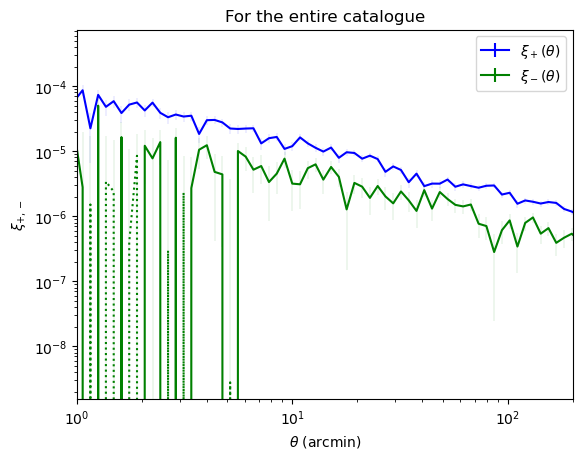

In [24]:
r = np.exp(gg.meanlogr)
xip = gg.xip
xim = gg.xim
sig = np.sqrt(gg.varxip)

plt.plot(r, xip, color='blue')
plt.plot(r, -xip, color='blue', ls=':')
plt.errorbar(r[xip>0], xip[xip>0], yerr=sig[xip>0], color='blue', lw=0.1, ls='')
plt.errorbar(r[xip<0], -xip[xip<0], yerr=sig[xip<0], color='blue', lw=0.1, ls='')
lp = plt.errorbar(-r, xip, yerr=sig, color='blue')

plt.plot(r, xim, color='green')
plt.plot(r, -xim, color='green', ls=':')
plt.errorbar(r[xim>0], xim[xim>0], yerr=sig[xim>0], color='green', lw=0.1, ls='')
plt.errorbar(r[xim<0], -xim[xim<0], yerr=sig[xim<0], color='green', lw=0.1, ls='')
lm = plt.errorbar(-r, xim, yerr=sig, color='green')

plt.xscale('log')
plt.yscale('log', nonpositive='clip')
plt.xlabel(r'$\theta$ (arcmin)')

plt.legend([lp, lm], [r'$\xi_+(\theta)$', r'$\xi_-(\theta)$'])
plt.xlim( [1,200] )
plt.ylabel(r'$\xi_{+,-}$')
plt.title("For the entire catalogue")
plt.show()

## dividing the data based on the photmetric redshift bins

In [25]:
dat1 = dat[(zb>=0.1) & (zb<=0.3)]
dat2 = dat[(zb>=0.3) & (zb<=0.5)]
dat3 = dat[(zb>=0.5) & (zb<=0.7)]
dat4 = dat[(zb>=0.7) & (zb<=0.9)]
dat5 = dat[(zb>=0.9) & (zb<=1.2)]


In [26]:
ra_1,dec_1,g1_1,g2_1,w1 = dat1['RAJ2000'], dat1['DECJ2000'], dat1['e1'], dat1['e2'], dat1['weight']
ra_2,dec_2,g1_2,g2_2,w2 = dat2['RAJ2000'], dat2['DECJ2000'], dat2['e1'], dat2['e2'], dat2['weight']
ra_3,dec_3,g1_3,g2_3,w3 = dat3['RAJ2000'], dat3['DECJ2000'], dat3['e1'], dat3['e2'], dat3['weight']
ra_4,dec_4,g1_4,g2_4,w4 = dat4['RAJ2000'], dat4['DECJ2000'], dat4['e1'], dat4['e2'], dat4['weight']
ra_5,dec_5,g1_5,g2_5,w5 = dat5['RAJ2000'], dat5['DECJ2000'], dat5['e1'], dat5['e2'], dat5['weight']

In [27]:
cat1 = treecorr.Catalog(ra=ra_1, dec=dec_1, ra_units='deg', 
                    dec_units='deg',g1=g1_1, g2=g2_1, w=w1)
cat2 = treecorr.Catalog(ra=ra_2, dec=dec_2, ra_units='deg', 
                    dec_units='deg',g1=g1_2, g2=g2_2, w=w2)
cat3 = treecorr.Catalog(ra=ra_3, dec=dec_3, ra_units='deg', 
                    dec_units='deg',g1=g1_3, g2=g2_3, w=w3)
cat4 = treecorr.Catalog(ra=ra_4, dec=dec_4, ra_units='deg', 
                    dec_units='deg',g1=g1_4, g2=g2_4, w=w4)
cat5 = treecorr.Catalog(ra=ra_5, dec=dec_5, ra_units='deg', 
                    dec_units='deg',g1=g1_5, g2=g2_5, w=w5)

In [28]:
gg = treecorr.GGCorrelation(min_sep=0.1, max_sep=300, nbins=10, sep_units='arcmin')

In [29]:
gg.process(cat1)
#gg.process(cat4, cat5)

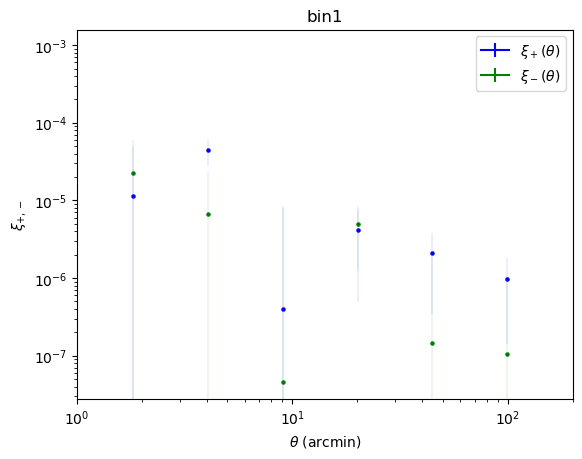

In [30]:
r = np.exp(gg.meanlogr)
xip = gg.xip
xim = gg.xim
sig = np.sqrt(gg.varxip)

plt.scatter(r, xip, color='blue',s=5)
plt.scatter(r, -xip, color='blue',s=5)
plt.errorbar(r[xip>0], xip[xip>0], yerr=sig[xip>0], color='blue', lw=0.1, ls='')
plt.errorbar(r[xip<0], -xip[xip<0], yerr=sig[xip<0], color='blue', lw=0.1, ls='')
lp = plt.errorbar(-r, xip, yerr=sig, color='blue')

plt.scatter(r, xim, color='green',s=5)
plt.scatter(r, -xim, color='green',s=5)
plt.errorbar(r[xim>0], xim[xim>0], yerr=sig[xim>0], color='green', lw=0.1, ls='')
plt.errorbar(r[xim<0], -xim[xim<0], yerr=sig[xim<0], color='green', lw=0.1, ls='')
lm = plt.errorbar(-r, xim, yerr=sig, color='green')

plt.xscale('log')
plt.yscale('log', nonpositive='clip')
plt.xlabel(r'$\theta$ (arcmin)')

plt.legend([lp, lm], [r'$\xi_+(\theta)$', r'$\xi_-(\theta)$'])
plt.xlim( [1,200] )
plt.ylabel(r'$\xi_{+,-}$')
plt.title("bin1")
plt.show()

In [31]:
# Saving the data for each correlation functions

#save_val = np.array([r, xip, xim, sig]).T

#np.savetxt('bin4-5.txt',save_val)

In [32]:
treecorr.Catalog?

Init signature:
treecorr.Catalog(
    file_name=None,
    config=None,
    *,
    num=0,
    logger=None,
    is_rand=False,
    x=None,
    y=None,
    z=None,
    ra=None,
    dec=None,
    r=None,
    w=None,
    wpos=None,
    flag=None,
    k=None,
    z1=None,
    z2=None,
    v1=None,
    v2=None,
    g1=None,
    g2=None,
    t1=None,
    t2=None,
    q1=None,
    q2=None,
    patch=None,
    patch_centers=None,
    rng=None,
    **kwargs,
)
Docstring:     
A set of input data (positions and other quantities) to be correlated.

A Catalog object keeps track of the relevant information for a number of objects to
be correlated.  The objects each have some kind of position (for instance (x,y), (ra,dec),
(x,y,z), etc.), and possibly some extra information such as weights (w), shear values (g1,g2),
scalar values (k), or vector values (v1,v2).

.. note::

    See `Shear Conventions` for some discussion of the conventions used in TreeCorr
    for the orientation of the shear values.

T

# Plotting the correlation functions using the saved datafiles

In [33]:
dat11   = np.loadtxt('/user/p5_group/Rudrani/shear/bin1.txt')
dat22   = np.loadtxt('/user/p5_group/Rudrani/shear/bin2.txt')
dat33   = np.loadtxt('/user/p5_group/Rudrani/shear/bin3.txt')
dat44   = np.loadtxt('/user/p5_group/Rudrani/shear/bin4.txt')
dat55   = np.loadtxt('/user/p5_group/Rudrani/shear/bin5.txt')
dat12  = np.loadtxt('/user/p5_group/Rudrani/shear/bin1-2.txt')
dat13  = np.loadtxt('/user/p5_group/Rudrani/shear/bin1-3.txt')
dat14  = np.loadtxt('/user/p5_group/Rudrani/shear/bin1-4.txt')
dat15  = np.loadtxt('/user/p5_group/Rudrani/shear/bin1-5.txt')
dat23  = np.loadtxt('/user/p5_group/Rudrani/shear/bin2-3.txt')
dat24  = np.loadtxt('/user/p5_group/Rudrani/shear/bin2-4.txt')
dat25  = np.loadtxt('/user/p5_group/Rudrani/shear/bin2-5.txt')
dat34  = np.loadtxt('/user/p5_group/Rudrani/shear/bin3-4.txt')
dat35  = np.loadtxt('/user/p5_group/Rudrani/shear/bin3-5.txt')
dat45  = np.loadtxt('/user/p5_group/Rudrani/shear/bin4-5.txt')

## Reporducing Fig. 5 of Asgari+20

(-2.0, 4.0)

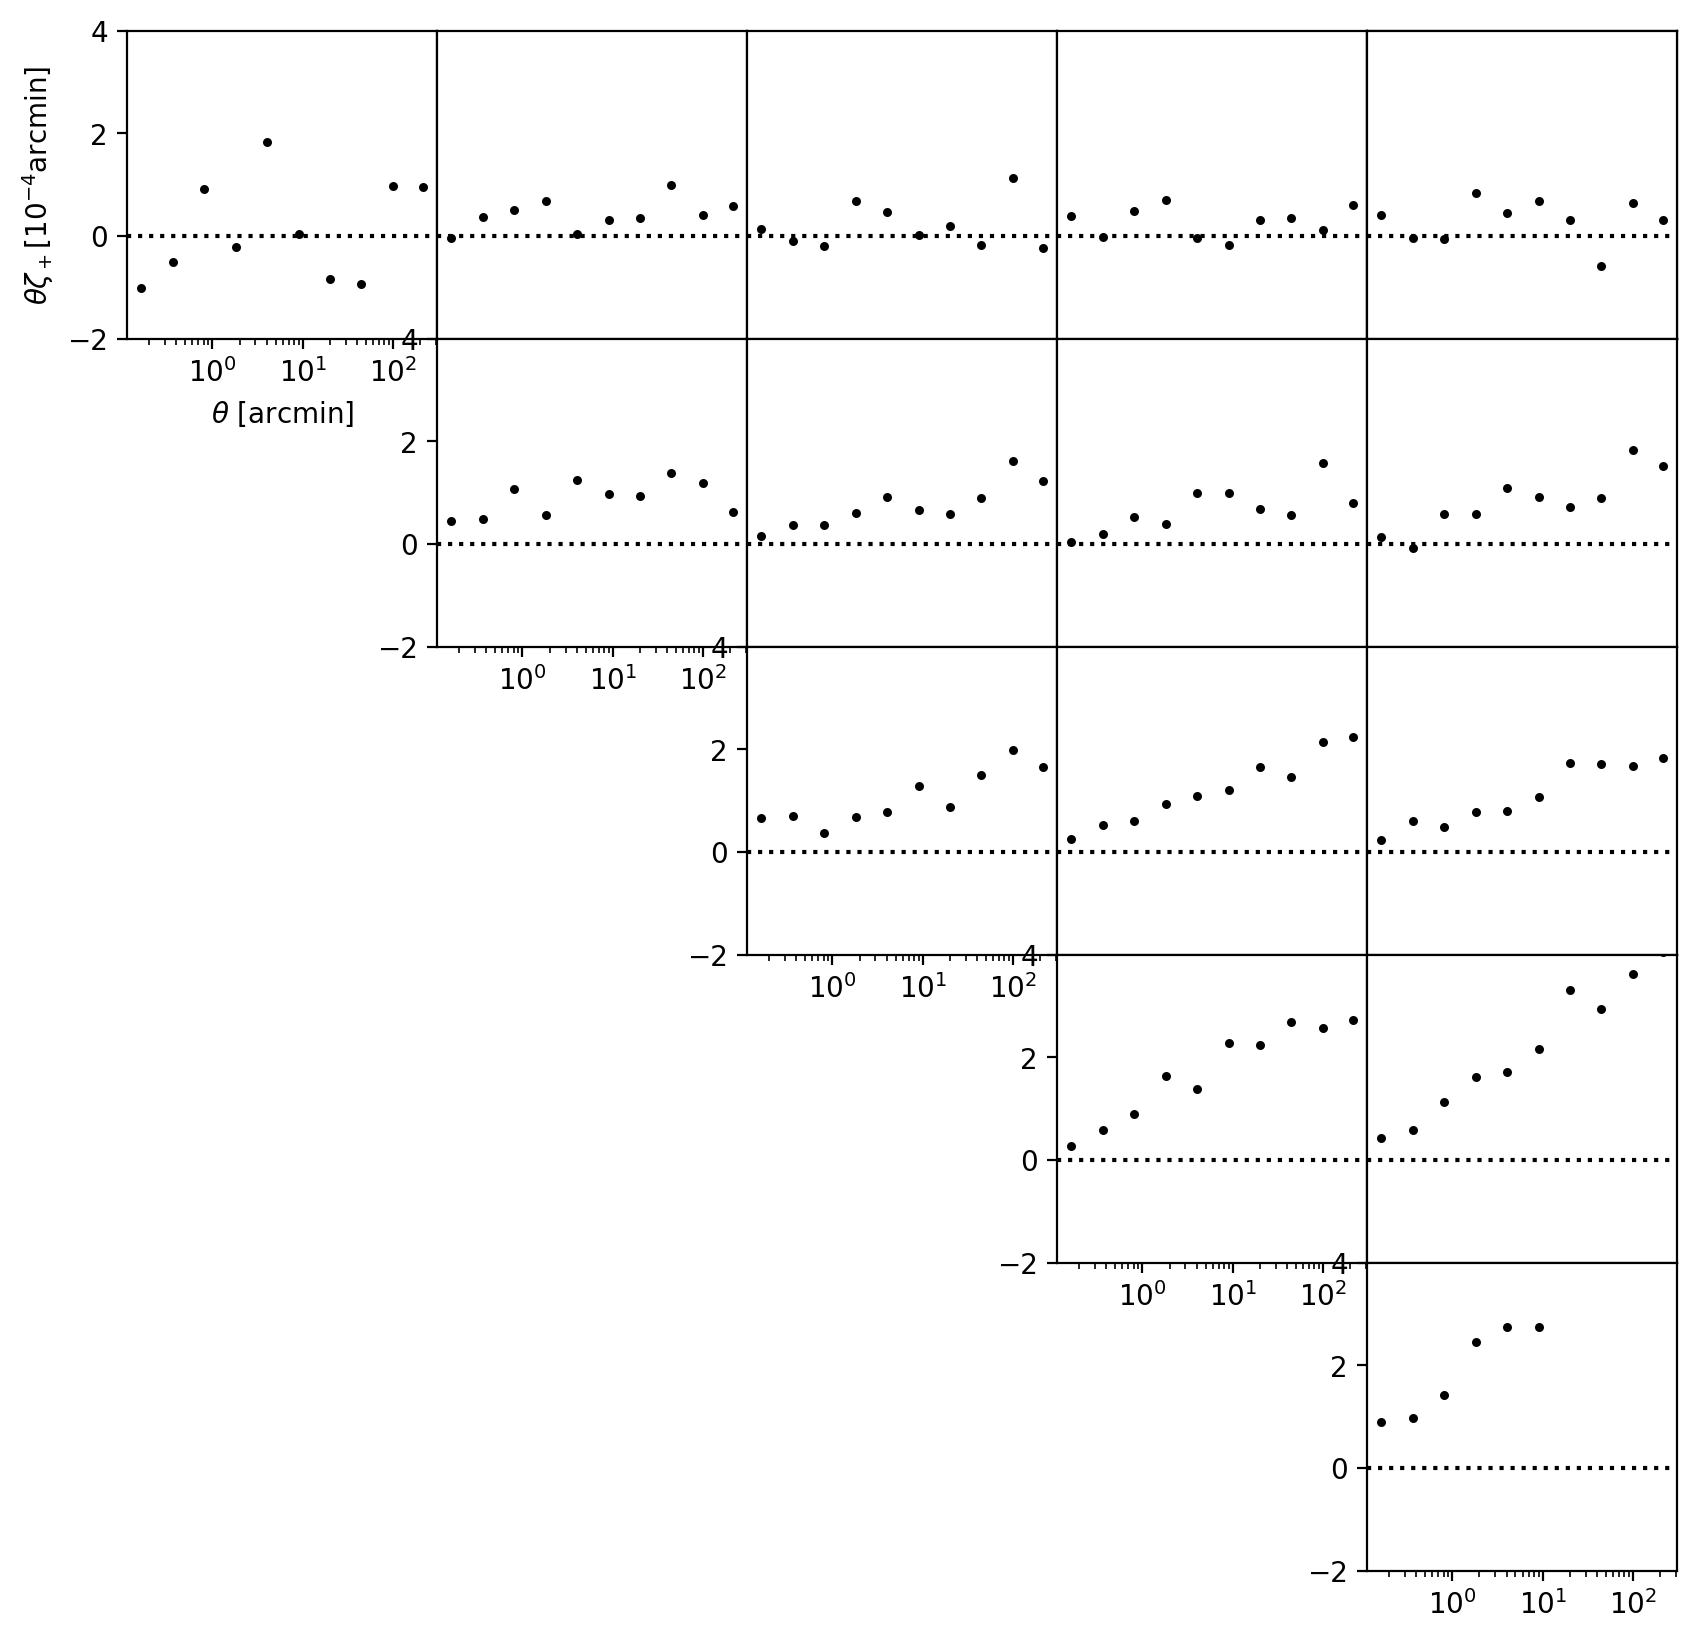

In [34]:
fig          =     plt.figure(figsize=(10,10), dpi=200)
fig.subplots_adjust(wspace=0, hspace=0)
gs           =     GridSpec(5, 5, figure=fig)

ax           =     fig.add_subplot(gs[0, 0])
plt.scatter(dat11[:,0], (dat11[:,0]*dat11[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')
plt.ylabel(r'$\theta \zeta_+ [10^{-4} \text{arcmin}]$')
plt.xlabel(r'$\theta$ [arcmin]')

ax           =     fig.add_subplot(gs[0, 1])
plt.scatter(dat12[:,0], (dat12[:,0]*dat12[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[0, 2])
plt.scatter(dat13[:,0], (dat13[:,0]*dat13[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[0, 3])
plt.scatter(dat14[:,0], (dat14[:,0]*dat14[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[0, 4])
plt.scatter(dat15[:,0], (dat15[:,0]*dat15[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[0, 4])
plt.scatter(dat15[:,0], (dat15[:,0]*dat15[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[1, 1])
plt.scatter(dat22[:,0], (dat22[:,0]*dat22[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[1, 2])
plt.scatter(dat23[:,0], (dat23[:,0]*dat23[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[1, 3])
plt.scatter(dat24[:,0], (dat24[:,0]*dat24[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[1, 4])
plt.scatter(dat25[:,0], (dat25[:,0]*dat25[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[2, 2])
plt.scatter(dat33[:,0], (dat33[:,0]*dat33[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[2, 3])
plt.scatter(dat34[:,0], (dat34[:,0]*dat34[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[2, 4])
plt.scatter(dat35[:,0], (dat35[:,0]*dat35[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[3, 3])
plt.scatter(dat44[:,0], (dat44[:,0]*dat44[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[3, 4])
plt.scatter(dat45[:,0], (dat45[:,0]*dat45[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.yticks([])
plt.xticks([])
plt.ylim([-2,4])
plt.axhline(0,ls=':',c='k')

ax           =     fig.add_subplot(gs[4, 4])
plt.scatter(dat55[:,0], (dat55[:,0]*dat55[:,1])/1e-4, s=5,c='k')
plt.xscale('log')
plt.axhline(0,ls=':',c='k')
plt.ylim([-2,4])

## A much nicer plot with help from Gemini

In [35]:
data_map = {
    (0, 0): dat11,  (0, 1): dat12, (0, 2): dat13, (0, 3): dat14, (0, 4): dat15,
                   (1, 1): dat22,  (1, 2): dat23, (1, 3): dat24, (1, 4): dat25,
                                  (2, 2): dat33,  (2, 3): dat34, (2, 4): dat35,
                                                 (3, 3): dat44,  (3, 4): dat45,
                                                                (4, 4): dat55,
}

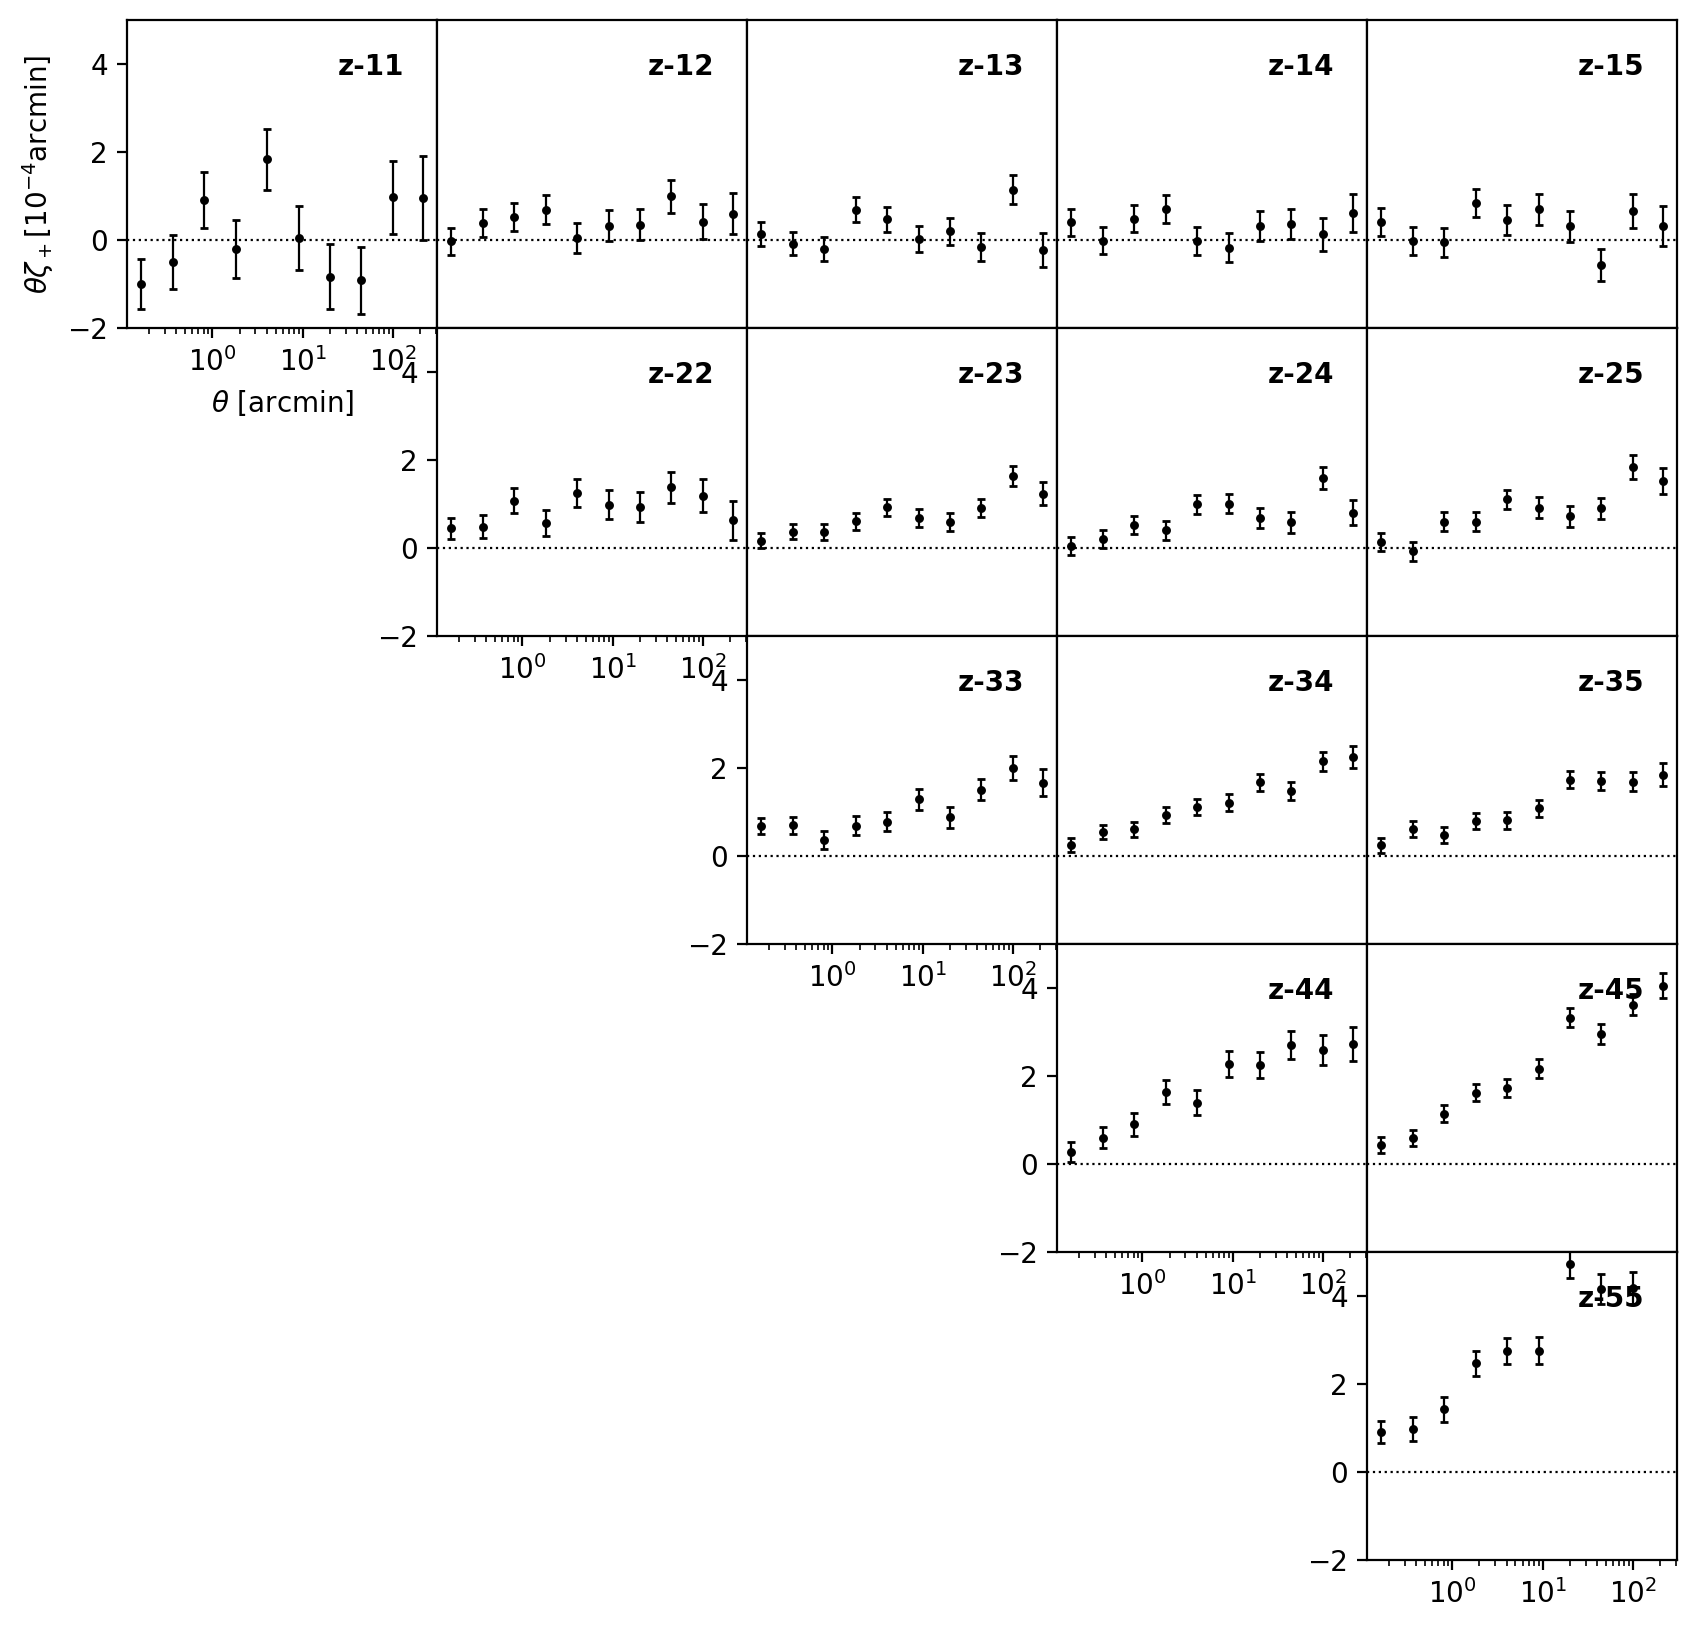

In [36]:
fig = plt.figure(figsize=(10, 10), dpi=200)
fig.subplots_adjust(wspace=0, hspace=0)
gs = GridSpec(5, 5, figure=fig)

for row in range(5):
    for col in range(row, 5):
        ax = fig.add_subplot(gs[row, col])
        DAT = data_map[(row, col)]

        x = DAT[:, 0]
        y = DAT[:, 1]
        yerr = DAT[:, 3]

        y_scaled = (x * y) / 1e-4
        yerr_scaled = (np.abs(x) * yerr) / 1e-4

        ax.errorbar(
            x, y_scaled, yerr=yerr_scaled,
            fmt='o', color='k', markersize=2.2, elinewidth=0.8, capsize=1.5
        )

        label_text = f"z-{row + 1}{col + 1}"
        ax.text(
            0.68, 0.82,
            label_text,
            transform=ax.transAxes,
            fontsize=10,
            fontweight='bold',
            color='black'
        )

        ax.set_xscale('log')
        ax.set_ylim([-2, 5])
        ax.axhline(0, ls=':', c='k', lw=0.8)

        if row == 0 and col == 0:
            ax.set_ylabel(r'$\theta \zeta_+ [10^{-4} \text{arcmin}]$')
            ax.set_xlabel(r'$\theta$ [arcmin]')
        
        if row != col:
            ax.set_xticks([])
            ax.set_yticks([])

plt.show()

## Overplotting data from fig.5 of Asgari et al. 2020

In [37]:
# First checking the data
with fits.open('/user/p5_group/Rudrani/shear/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits') as hdul:
    hd0 = hdul[0].header
    hd1 = hdul[1].header
    hd2 = hdul[2].header
    hd3 = hdul[3].header
    hd4 = hdul[4].header
    dt0 = hdul[0].data
    dt1 = hdul[1].data
    dt2 = hdul[2].data
    dt3 = hdul[3].data
    dt4 = hdul[4].data

print("How to know this is corresponding to errorbar of the paper?")
fits.getdata('/user/p5_group/Rudrani/shear/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits',1)

How to know this is corresponding to errorbar of the paper?


array([[7.61755989e-09, 1.67773794e-12, 1.16065823e-12, ...,
        8.77729973e-14, 4.79746541e-14, 2.72503313e-14],
       [1.67773794e-12, 1.95695084e-09, 1.10448600e-12, ...,
        7.18013536e-14, 3.92197291e-14, 2.20409033e-14],
       [1.16065823e-12, 1.10448600e-12, 5.06410377e-10, ...,
        5.38570895e-14, 2.96060559e-14, 1.64761880e-14],
       ...,
       [7.64057567e-14, 6.55377070e-14, 5.07305861e-14, ...,
        6.06811224e-13, 2.78258503e-14, 8.61494018e-15],
       [4.03024155e-14, 3.46818100e-14, 2.71135619e-14, ...,
        2.78258503e-14, 2.15217698e-13, 1.68321133e-14],
       [2.24467054e-14, 1.90199518e-14, 1.46942027e-14, ...,
        8.61494018e-15, 1.68321133e-14, 1.04001415e-13]],
      shape=(270, 270), dtype='>f8')

In [38]:
data_cov = fits.getdata('/user/p5_group/Rudrani/shear/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits',1)
data_xip = fits.getdata('/user/p5_group/Rudrani/shear/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits',2)
data_xim = fits.getdata('/user/p5_group/Rudrani/shear/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits',3)

In [39]:
data_cov.shape, data_xip.shape, data_xim.shape

((270, 270), (135,), (135,))

In [40]:
var = np.diag(data_cov)
data_err = np.sqrt(var)
data_err_xip = data_err[0:135]
data_err_xim = data_err[135:270]

In [41]:
print(data_xip)

[(1, 1, 1,  1.25115625e-04,   0.71336491)
 (1, 1, 2,  6.00683567e-06,   1.45209561)
 (1, 1, 3,  6.19317502e-05,   2.95582478)
 (1, 1, 4,  2.11742421e-06,   6.01675264)
 (1, 1, 5, -2.92882256e-06,  12.24744871)
 (1, 1, 6, -2.38991012e-06,  24.93039168)
 (1, 1, 7, -1.56889835e-06,  50.74725716)
 (1, 1, 8,  1.61541556e-07, 103.29898312)
 (1, 1, 9, -3.29682598e-09, 210.27106705)
 (1, 2, 1,  5.11868980e-05,   0.71336491)
 (1, 2, 2,  2.82597971e-05,   1.45209561)
 (1, 2, 3,  4.33571094e-06,   2.95582478)
 (1, 2, 4,  9.95191063e-06,   6.01675264)
 (1, 2, 5,  2.48591965e-06,  12.24744871)
 (1, 2, 6,  8.84065085e-07,  24.93039168)
 (1, 2, 7,  1.98120807e-06,  50.74725716)
 (1, 2, 8,  3.05569286e-07, 103.29898312)
 (1, 2, 9,  1.07653468e-07, 210.27106705)
 (1, 3, 1, -3.04513359e-05,   0.71336491)
 (1, 3, 2,  3.86821643e-05,   1.45209561)
 (1, 3, 3,  2.01448230e-05,   2.95582478)
 (1, 3, 4,  4.62980257e-06,   6.01675264)
 (1, 3, 5, -8.35707663e-07,  12.24744871)
 (1, 3, 6,  3.89650561e-07,  24.93

In [42]:
bin1, bin2 = data_xip['BIN1'], data_xip['BIN2']
xip, theta = data_xip['VALUE'], data_xip['ANG']

In [43]:
xip_dict    =    {}
theta_dict  =    {}
err_dict    =    {}

for b1 in range(1, 6):
    for b2 in range(b1, 6):
        mask = (bin1 == b1) & (bin2 == b2)
        xip_dict[(b1, b2)] = xip[mask]
        theta_dict[(b1, b2)] = theta[mask]
        err_dict[(b1, b2)] = data_err_xip[mask]

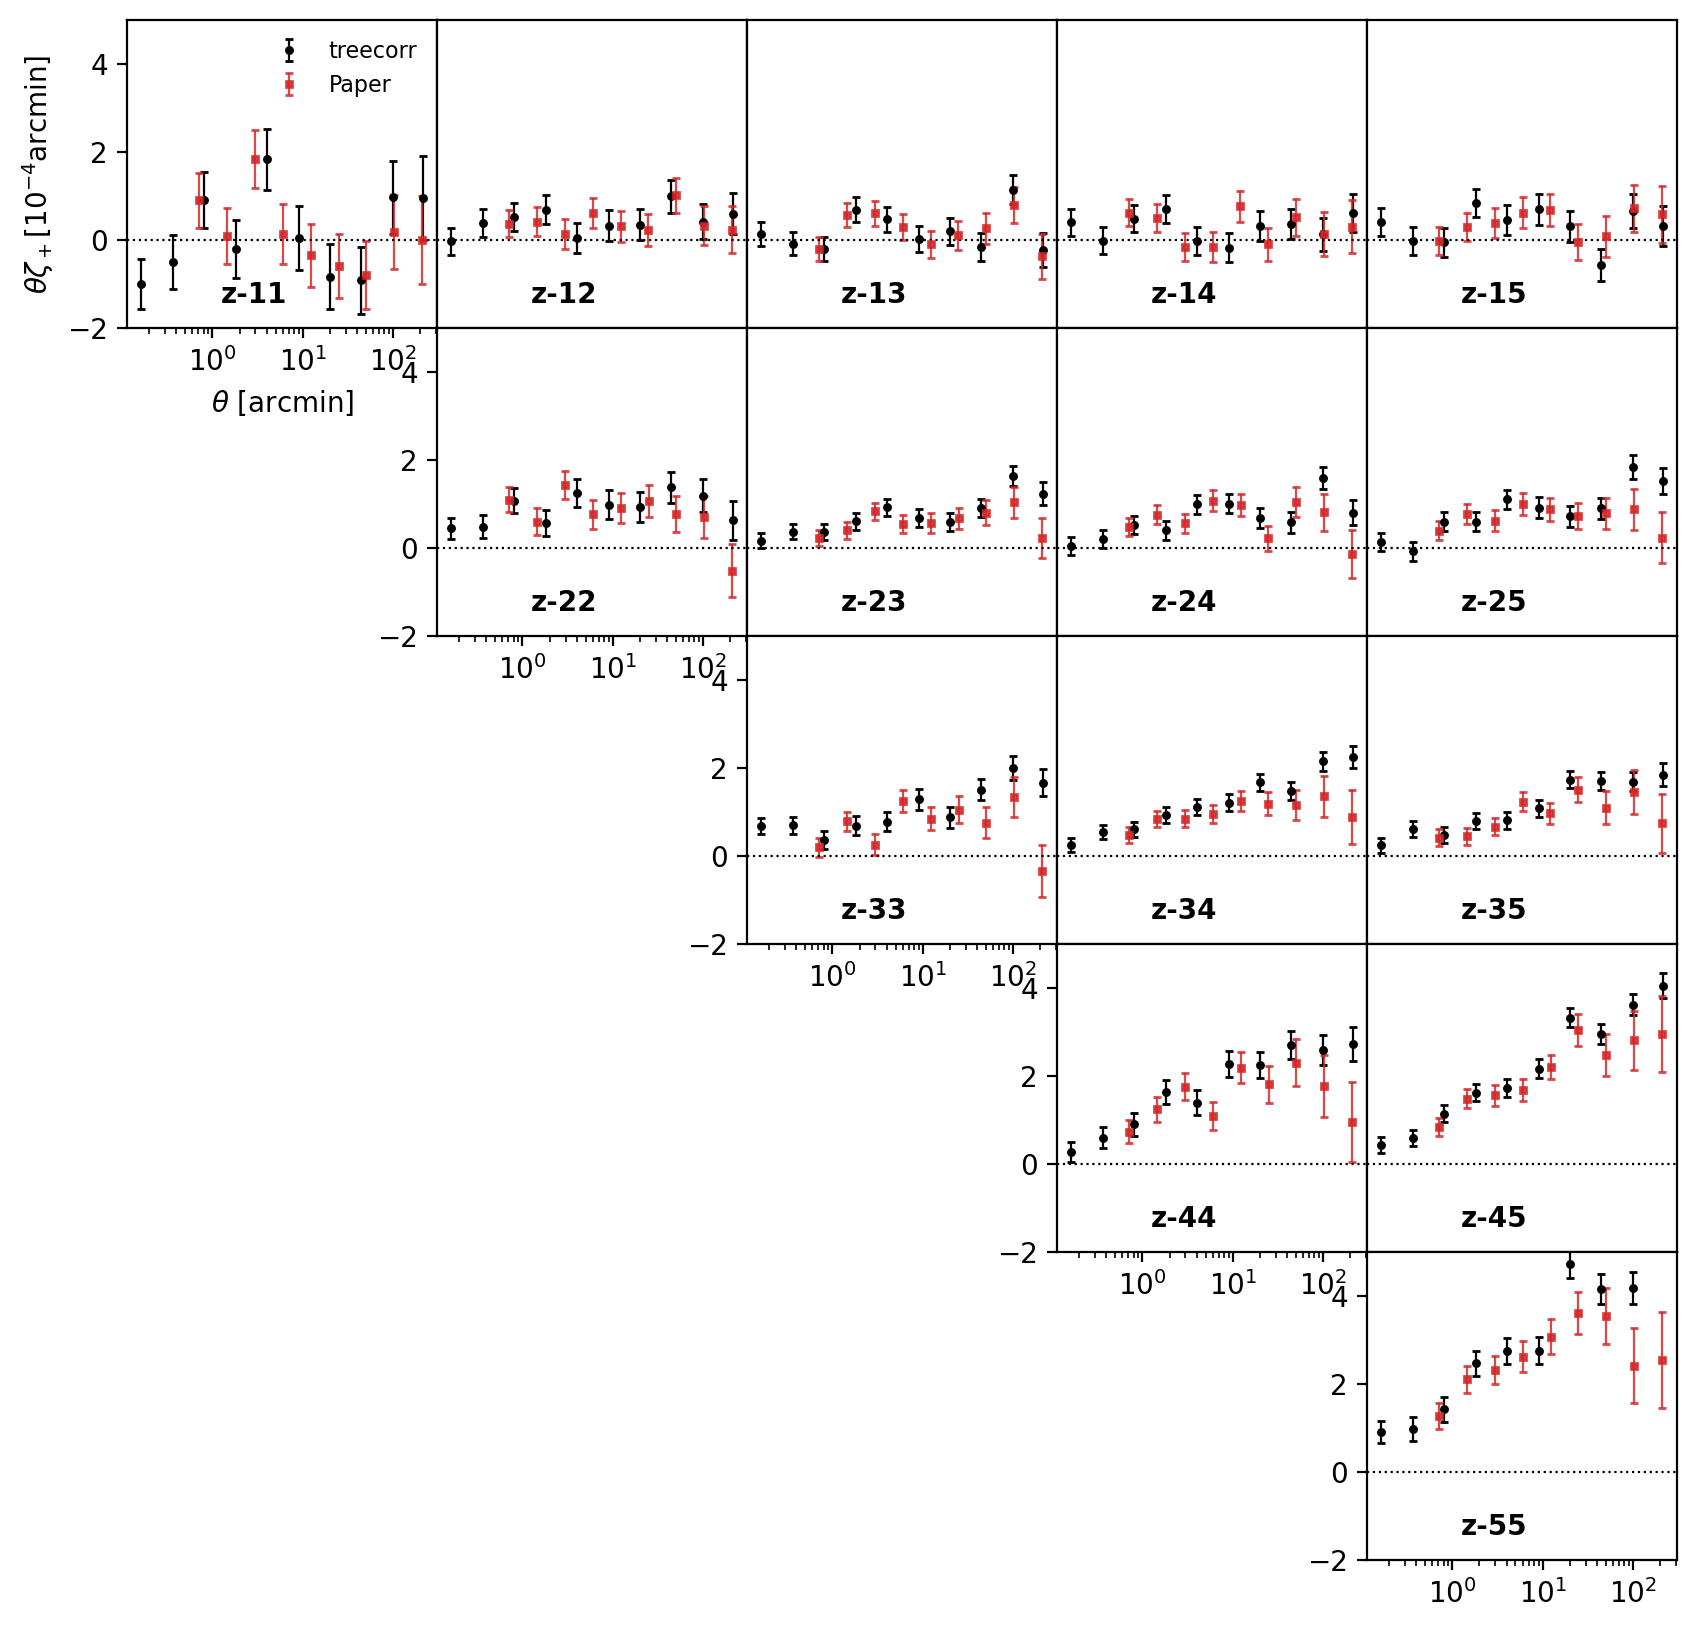

In [44]:
fig = plt.figure(figsize=(10, 10), dpi=200)
fig.subplots_adjust(wspace=0, hspace=0)
gs = GridSpec(5, 5, figure=fig)

for row in range(5):
    for col in range(row, 5):
        ax = fig.add_subplot(gs[row, col])
        
        Dat = data_map[(row, col)]
        x = Dat[:, 0]
        y = Dat[:, 1]
        yerr = Dat[:, 3]

        y_scaled = (x * y) / 1e-4
        yerr_scaled = (np.abs(x) * yerr) / 1e-4

        ax.errorbar(
            x, y_scaled, yerr=yerr_scaled,
            fmt='o', color='k', markersize=2.2, elinewidth=0.8, capsize=1.5,
            label='treecorr' if (row == 0 and col == 0) else ""
        )

        b1, b2 = row + 1, col + 1
        theta_paper = theta_dict[(b1, b2)]
        xip_paper = xip_dict[(b1, b2)]
        err_paper = err_dict[(b1, b2)]
        
        xip_paper_scaled = (theta_paper * xip_paper) / 1e-4
        err_paper_scaled = (np.abs(theta_paper) * err_paper) / 1e-4

        ax.errorbar(
            theta_paper, xip_paper_scaled, yerr=err_paper_scaled,
            fmt='s', color='tab:red', markersize=2.0, lw=1.0,
            elinewidth=0.8, capsize=1.5, alpha=0.85, 
            label='Paper' if (row == 0 and col == 0) else ""
        )

        ax.text(
            0.3, 0.08, f"z-{b1}{b2}",
            transform=ax.transAxes,
            fontsize=10, fontweight='bold', color='black'
        )

        ax.set_xscale('log')
        ax.set_ylim([-2, 5])
        ax.axhline(0, ls=':', c='k', lw=0.8)

        if row == 0 and col == 0:
            ax.set_ylabel(r'$\theta \zeta_+ [10^{-4} \text{arcmin}]$')
            ax.set_xlabel(r'$\theta$ [arcmin]')
            ax.legend(frameon=False, fontsize=8, loc='upper right')
        
        if row != col:
            ax.set_xticks([])
            ax.set_yticks([])

plt.show()

## Calculating multiplicative and additive bias

In [46]:
m = [-0.009, -0.011, -0.015, 0.002, 0.007]

In [47]:
def compute_c_bias(cat_data):
    w = cat_data['weight']
    e1 = cat_data['e1']
    e2 = cat_data['e2']
    
    w_sum = np.sum(w)
    c1 = np.sum(w * e1) / w_sum
    c2 = np.sum(w * e2) / w_sum
    
    return c1, c2

In [48]:
compute_c_bias(dat1)

(np.float32(0.00012348704), np.float32(0.00014027972))

In [76]:
gg = treecorr.GGCorrelation(min_sep=0.1, max_sep=300, nbins=10, sep_units='arcmin')
RA = [ra_1, ra_2, ra_3, ra_4, ra_5]
DEC = [dec_1, dec_2, dec_3, dec_4, dec_5]
G1 = [g1_1-compute_c_bias(dat1)[0], g1_2-compute_c_bias(dat2)[0], g1_3-compute_c_bias(dat3)[0], g1_4-compute_c_bias(dat4)[0], g1_5-compute_c_bias(dat5)[0]]
G2 = [g2_1-compute_c_bias(dat1)[1], g2_2-compute_c_bias(dat2)[1], g2_3-compute_c_bias(dat3)[1], g2_4-compute_c_bias(dat4)[1], g2_5-compute_c_bias(dat5)[1]]
W = [w1,w2,w3,w4,w5]

In [84]:
corr_par = {}

for i in range(1,6):
    for j in range(i,6):
        if i==j:
            cat = cat = treecorr.Catalog(ra=RA[i-1], dec=DEC[i-1], ra_units='deg', 
                    dec_units='deg',g1=G1[i-1], g2=G2[i-1], w=W[i-1])
            gg.process(cat)
            pair_data = {
                'theta': np.exp(gg1.meanlogr),
                'xip': gg.xip/(1+m[i-1])**2,
                'xim': gg.xim/(1+m[i-1])**2,
                'sig': np.sqrt(gg.varxip)
            }
            corr_par [(i, j)] = pair_data
        else:
            cat1 = treecorr.Catalog(ra=RA[i-1], dec=DEC[i-1], ra_units='deg', 
                    dec_units='deg',g1=G1[i-1], g2=G2[i-1], w=W[i-1])
            cat2 = treecorr.Catalog(ra=RA[j-1], dec=DEC[j-1], ra_units='deg', 
                    dec_units='deg',g1=G1[j-1], g2=G2[j-1], w=W[j-1])
            gg.process(cat)
            pair_data = {
                'theta': np.exp(gg1.meanlogr),
                'xip': gg.xip/((1+m[i-1])*(1+m[j-1])),
                'xim': gg.xim/((1+m[i-1])*(1+m[j-1])),
                'sig': np.sqrt(gg.varxip)
            }
            corr_par [(i, j)] = pair_data

corr_par

{(1,
  1): {'theta': array([1.63663398e-01, 3.65641403e-01, 8.16466414e-01, 1.81826493e+00,
         4.04516353e+00, 9.02382860e+00, 2.00941687e+01, 4.46288998e+01,
         9.89434747e+01, 2.16036365e+02]), 'xip': array([-6.26837246e-04, -1.39624211e-04,  1.13216435e-04, -1.17954795e-05,
          4.60245666e-05,  3.50236373e-07, -4.30804404e-06, -2.16650422e-06,
          9.29916319e-07,  3.71833253e-07]), 'xim': array([-9.20378936e-05,  3.78445599e-04,  1.90524488e-05,  2.31079576e-05,
          6.73947027e-06,  4.45615830e-08, -4.99167071e-06, -1.59245963e-07,
         -1.09348954e-07, -4.58796616e-07]), 'sig': array([3.50146406e-04, 1.67432276e-04, 7.84470656e-05, 3.65590136e-05,
         1.70807333e-05, 7.97688017e-06, 3.68583672e-06, 1.72739553e-06,
         8.33538407e-07, 4.43325324e-07])},
 (1,
  2): {'theta': array([1.63663398e-01, 3.65641403e-01, 8.16466414e-01, 1.81826493e+00,
         4.04516353e+00, 9.02382860e+00, 2.00941687e+01, 4.46288998e+01,
         9.89434747e+01,

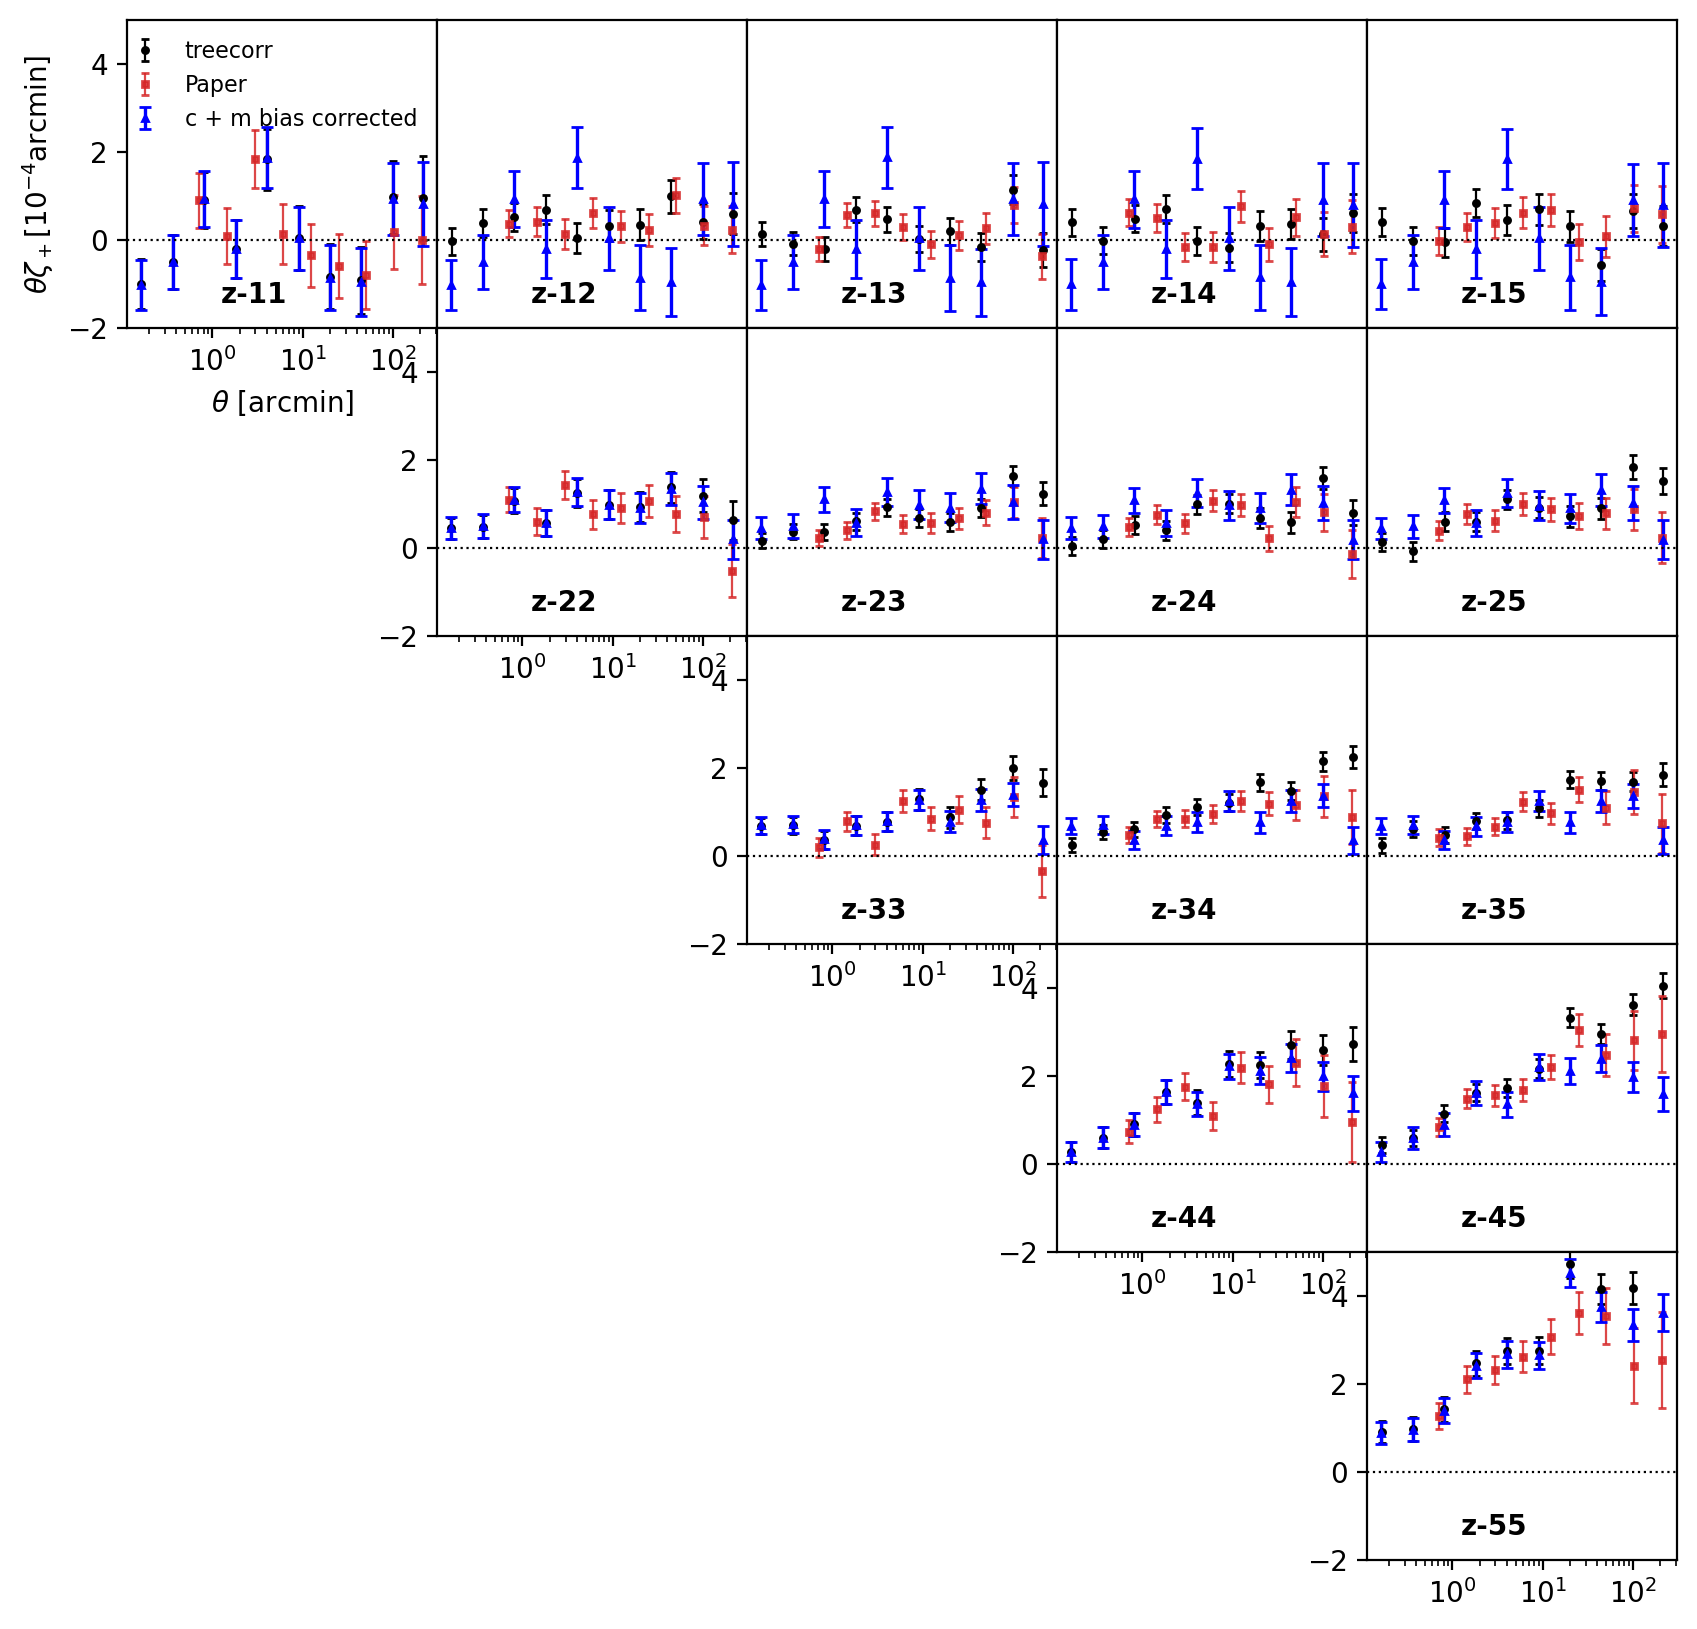

In [91]:
fig = plt.figure(figsize=(10, 10), dpi=200)
fig.subplots_adjust(wspace=0, hspace=0)
gs = GridSpec(5, 5, figure=fig)

for row in range(5):
    for col in range(row, 5):
        ax = fig.add_subplot(gs[row, col])
        
        Dat = data_map[(row, col)]
        x = Dat[:, 0]
        y = Dat[:, 1]
        yerr = Dat[:, 3]

        y_scaled = (x * y) / 1e-4
        yerr_scaled = (np.abs(x) * yerr) / 1e-4

        ax.errorbar(
            x, y_scaled, yerr=yerr_scaled,
            fmt='o', color='k', markersize=2.2, elinewidth=0.8, capsize=1.5,
            label='treecorr' if (row == 0 and col == 0) else ""
        )

        b1, b2 = row + 1, col + 1
        theta_paper = theta_dict[(b1, b2)]
        xip_paper = xip_dict[(b1, b2)]
        err_paper = err_dict[(b1, b2)]
        
        xip_paper_scaled = (theta_paper * xip_paper) / 1e-4
        err_paper_scaled = (np.abs(theta_paper) * err_paper) / 1e-4

        ax.errorbar(
            theta_paper, xip_paper_scaled, yerr=err_paper_scaled,
            fmt='s', color='tab:red', markersize=2.0, lw=1.0,
            elinewidth=0.8, capsize=1.5, alpha=0.85, 
            label='Paper' if (row == 0 and col == 0) else ""
        )

        bin1 = row + 1
        bin2 = col + 1

        if (bin1, bin2) in corr_par:
            data_corr = corr_par[(bin1, bin2)]
            t_corr = data_corr['theta']
            
            # Scale to (theta * xi_+) / 10^-4
            y_corr = t_corr * data_corr['xip'] * 1e4
            err_corr = t_corr * data_corr['sig'] * 1e4
            
            ax.errorbar(
                t_corr, y_corr, yerr=err_corr,
                fmt='^', markersize=2, color='b', linewidth=1.2,
                capsize=2, label='c + m bias corrected' if (row == 0 and col == 0) else ""
            )

        ax.text(
            0.3, 0.08, f"z-{b1}{b2}",
            transform=ax.transAxes,
            fontsize=10, fontweight='bold', color='black'
        )

        ax.set_xscale('log')
        ax.set_ylim([-2, 5])
        ax.axhline(0, ls=':', c='k', lw=0.8)

        if row == 0 and col == 0:
            ax.set_ylabel(r'$\theta \zeta_+ [10^{-4} \text{arcmin}]$')
            ax.set_xlabel(r'$\theta$ [arcmin]')
            ax.legend(frameon=False, fontsize=8, loc='upper right')
        
        if row != col:
            ax.set_xticks([])
            ax.set_yticks([])

plt.show()